In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from skimage import io, transform
from PIL import Image

# # Reload all modules imported with %aimport every time before executing the Python code typed
# # use if constantly editing .py script
# %load_ext autoreload
# %autoreload 1
# %aimport cell_segment

In [110]:
np.radians(180+0.046875)

3.1424107766766656

In [1]:
1 - .09375

0.90625

In [4]:
# Define the similarity transformation matrix
matrix_similarity = np.array(
    [[ 0.90625,  0.0390625,  16.0],
     [-0.0390625,  0.90625,  84.0],
     [0.000000,  0.000000,  1.000000]])
similarity_transform = transform.SimilarityTransform(matrix=matrix_similarity)


In [155]:
matrix_similarity = np.array(
    [[ 9.1796875e-01,  4.6874e-02,   3.00000],
     [-4.6874e-02,  9.1796875e-01,  82.00000],
     [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])
similarity_transform = transform.SimilarityTransform(matrix=matrix_similarity)

In [ ]:

# Define the preprocessing steps
yeaz_preprocesses = [
    lambda x: transform.rotate(x, 90),
    lambda x: transform.rescale(x, 0.25, anti_aliasing=True),
    lambda x: transform.warp(x, similarity_transform),
    lambda x: (x - x.min()) / (x.max() - x.min())
]

In [5]:
FOV1 = Image.open(f'C:\\Users\\admin\\OneDrive - Washington University in St. Louis\\PhD\\Research\\Biophys\\image_data\\ER-Mito_contact\\May152024\\BFFOV1_mask.tif')

In [6]:
FOV1io = io.imread(f'C:\\Users\\admin\\OneDrive - Washington University in St. Louis\\PhD\\Research\\Biophys\\image_data\\ER-Mito_contact\\May152024\\BFFOV1_mask.tif')

In [7]:
FOV1act = io.imread(f'C:\\Users\\admin\\OneDrive - Washington University in St. Louis\\PhD\\Research\\Biophys\\image_data\\ER-Mito_contact\\May152024\\BFFOV1_mask_rot90_resc.tif')

TiffPage 0: TypeError: read_bytes() missing 3 required positional arguments: 'dtype', 'count', and 'offsetsize'


In [8]:
FOV1img = io.imread(f'C:\\Users\\admin\\OneDrive - Washington University in St. Louis\\PhD\\Research\\Biophys\\image_data\\ER-Mito_contact\\May152024\\MAX_mixedFOV1.tif')

In [9]:
rot_matrix = transform.rotate(FOV1io, 90)
# resc = transform.rescale(rot_matrix, 0.25, anti_aliasing=True)

In [10]:
siml_transf = transform.warp(rot_matrix, similarity_transform)

In [11]:
final_mat = (siml_transf - siml_transf.min()) / (siml_transf.max() - siml_transf.min())

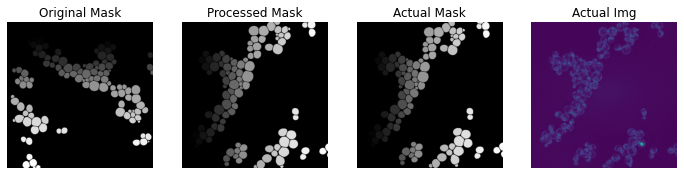

In [12]:
# Display the original and processed images
plt.figure(figsize=(12, 6))
plt.subplot(1, 4, 1)
plt.title('Original Mask')
plt.imshow(FOV1io, cmap='gray')
plt.axis('off')

# Display the processed image
plt.subplot(1, 4, 2)
plt.title('Processed Mask')
plt.imshow(final_mat, cmap='gray')
plt.axis('off')

# Display the actual image
plt.subplot(1, 4, 3)
plt.title('Actual Mask')
plt.imshow(FOV1act, cmap='gray')
plt.axis('off')

# Display the actual image
plt.subplot(1, 4, 4)
plt.title('Actual Img')
plt.imshow(FOV1img, cmap='viridis')
plt.axis('off')

plt.show()

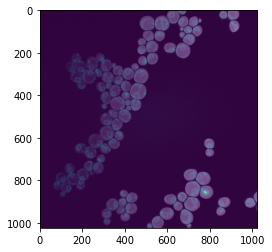

In [13]:
plt.imshow(FOV1img, cmap='viridis')
plt.imshow(final_mat, cmap='gray', alpha=0.3)
plt.show()

In [122]:
final_mat.shape

(1024, 1024)